# Static Dashboard: Sanctions and Civilian Well-Being

## Objective
This notebook presents a static dashboard that communicates the main findings of the project. The dashboard uses cleaned data, engineered features, and model outputs to explain how sanctions relate to civilian well-being.

The dashboard focuses on:
- overall model performance
- comparison of actual vs predicted child mortality
- the most influential model features
- trends in sanctions and well-being over time
- interactive filtering using widgets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

## Load Dashboard Data Sources

I load the saved outputs from the wrangling and modeling notebooks. These files provide the inputs needed for the dashboard, including model metrics, test predictions, feature importance information, and the feature-engineered dataset used for trend-based visuals.

In [2]:
metrics_df = pd.read_csv("../data/processed/model_metrics.csv")
test_preds_df = pd.read_csv("../data/processed/test_predictions.csv")
coef_df = pd.read_csv("../data/processed/linear_model_coefficients.csv")
feature_df = pd.read_csv("../data/processed/feature_engineered_dataset.csv")

print("Metrics shape:", metrics_df.shape)
print("Test predictions shape:", test_preds_df.shape)
print("Coefficients shape:", coef_df.shape)
print("Feature-engineered dataset shape:", feature_df.shape)

Metrics shape: (3, 4)
Test predictions shape: (2438, 3)
Coefficients shape: (39, 3)
Feature-engineered dataset shape: (7820, 46)


## Dashboard Summary Text

Before showing the charts, I include a short written summary so the viewer understands what the dashboard is meant to communicate.

This project studies how international sanctions relate to civilian well-being using a country-year panel dataset. The baseline regression model predicts child mortality using economic, political, conflict, trade, and sanction-related features. The visuals below summarize model performance, prediction quality, influential features, and selected trends over time.

## Dashboard Design Planning

Before building the dashboard, I identified the main message I wanted the visuals to communicate:

**Sanctions may be associated with civilian well-being outcomes, and this relationship can be explored through model performance, prediction quality, feature influence, and trends over time.**

To organize the dashboard clearly, I planned it around these questions:

1. How well does the model perform?
2. How close are the predictions to the actual values?
3. Which features seem most influential?
4. How do child mortality and sanction-related measures change over time?
5. How do outcomes differ between sanctioned and non-sanctioned observations?

This planning step helped make sure that the dashboard visuals support one coherent story instead of appearing as unrelated charts.

In [3]:
dashboard_plan_df = pd.DataFrame({
    "Dashboard Section": [
        "Model Performance",
        "Prediction Quality",
        "Feature Influence",
        "Time Trends",
        "Group Comparison",
        "Error Analysis"
    ],
    "Main Question": [
        "How well does the model perform across train, validation, and test data?",
        "How close are predicted values to actual child mortality values?",
        "Which variables appear most important in the model?",
        "How do child mortality and sanction indicators change over time?",
        "How does average child mortality differ by sanction status?",
        "Where does the model make larger prediction errors?"
    ],
    "Visualization Used": [
        "Bar charts for R² and RMSE",
        "Actual vs predicted scatter plot",
        "Coefficient chart / importance chart",
        "Widget-based line charts",
        "Bar chart by sanction status",
        "Residual distribution histogram"
    ]
})

dashboard_plan_df

,Dashboard Section,Main Question,Visualization Used
0,Model Performance,"How well does the model perform across train, ...",Bar charts for R² and RMSE
1,Prediction Quality,How close are predicted values to actual child...,Actual vs predicted scatter plot
2,Feature Influence,Which variables appear most important in the m...,Coefficient chart / importance chart
3,Time Trends,How do child mortality and sanction indicators...,Widget-based line charts
4,Group Comparison,How does average child mortality differ by san...,Bar chart by sanction status
5,Error Analysis,Where does the model make larger prediction er...,Residual distribution histogram


This table acts as a dashboard planning artifact. It shows how each visual was selected to answer a specific question and support the overall project message. In other words, the dashboard was designed to communicate results clearly, not just to display charts.

## Visual 1: Model Performance by Data Split

This chart compares model performance across the training, validation, and test sets. It helps show how the leakage-reduced baseline model generalizes to unseen data.

For this project, lower MAE and RMSE are better, while higher R² is better.

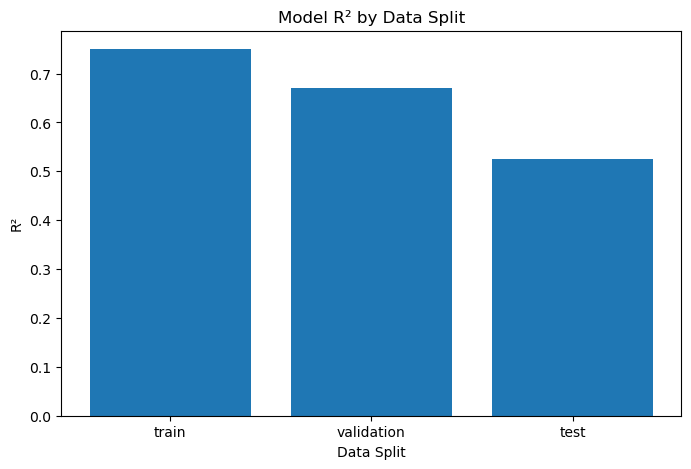

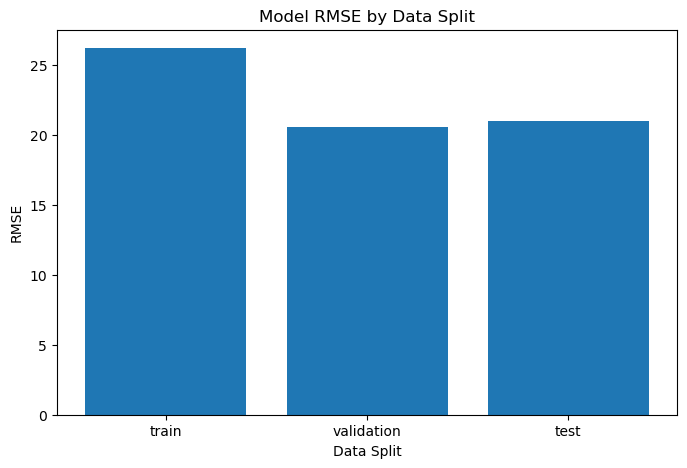

In [4]:
metrics_plot_df = metrics_df.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metrics_plot_df["split"], metrics_plot_df["R2"])
ax.set_title("Model R² by Data Split")
ax.set_xlabel("Data Split")
ax.set_ylabel("R²")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metrics_plot_df["split"], metrics_plot_df["RMSE"])
ax.set_title("Model RMSE by Data Split")
ax.set_xlabel("Data Split")
ax.set_ylabel("RMSE")
plt.show()

## Visual 2: Actual vs Predicted Child Mortality on the Test Set

This plot compares the actual child mortality values with the model’s predicted values on the held-out test set. If the predictions align well with the actual values, the points should fall close to the diagonal reference line.

This is one of the most useful visuals for understanding prediction quality in a regression task.

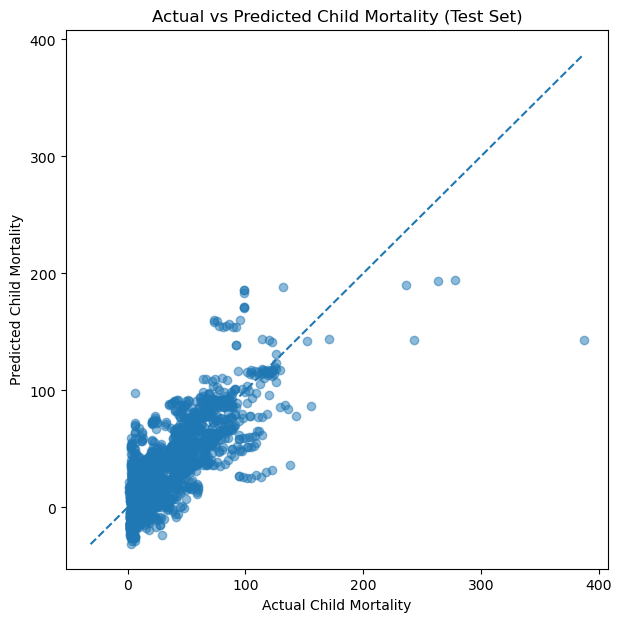

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    test_preds_df["actual_child_mortality_u5"],
    test_preds_df["predicted_child_mortality_u5"],
    alpha=0.5
)

min_val = min(
    test_preds_df["actual_child_mortality_u5"].min(),
    test_preds_df["predicted_child_mortality_u5"].min()
)
max_val = max(
    test_preds_df["actual_child_mortality_u5"].max(),
    test_preds_df["predicted_child_mortality_u5"].max()
)

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.set_title("Actual vs Predicted Child Mortality (Test Set)")
ax.set_xlabel("Actual Child Mortality")
ax.set_ylabel("Predicted Child Mortality")
plt.show()

## Visual 3: Most Influential Features in the Baseline Model

This plot shows the features with the largest absolute coefficients in the leakage-reduced linear regression model. These coefficients represent associations with the target, not causal effects, but they help identify which features were most influential in the baseline model.

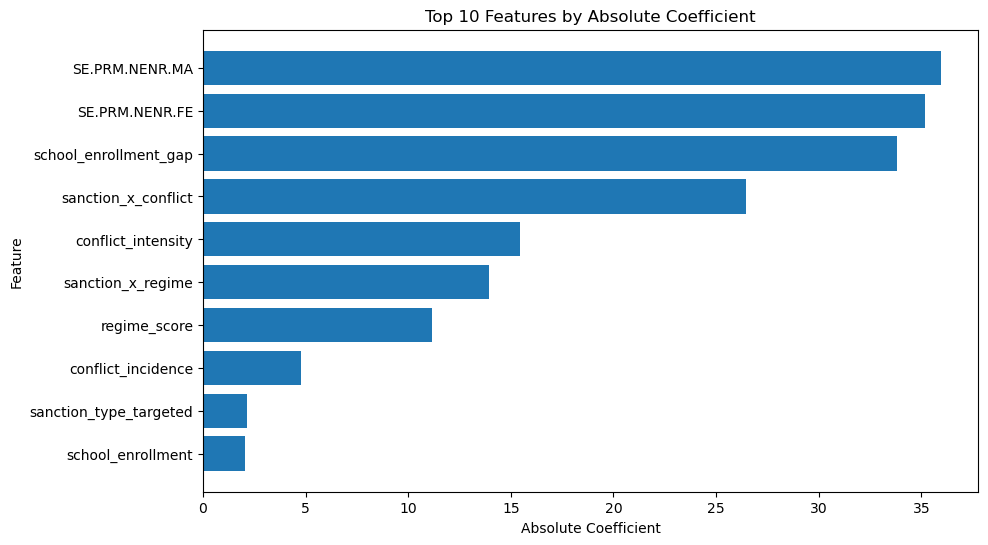

In [6]:
top_coef_df = coef_df.sort_values("abs_coefficient", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_coef_df["feature"], top_coef_df["abs_coefficient"])
ax.set_title("Top 10 Features by Absolute Coefficient")
ax.set_xlabel("Absolute Coefficient")
ax.set_ylabel("Feature")
ax.invert_yaxis()
plt.show()

## Prepare Data for Interactive Trend Views

To support a widget-based static dashboard, I create a smaller aggregated table that summarizes child mortality and sanction activity by year. This will allow the viewer to switch between different trends using simple controls.

In [7]:
trend_df = feature_df.groupby("year").agg(
    avg_child_mortality=("child_mortality_u5", "mean"),
    avg_sanction_intensity=("sanction_intensity_index", "mean"),
    sanctioned_share=("sanction_active", "mean")
).reset_index()

trend_df.head()

,year,avg_child_mortality,avg_sanction_intensity,sanctioned_share
0,1995,68.968375,0.000000,0.000000
1,1996,67.234901,0.000000,0.000000
2,1997,65.423114,0.000000,0.000000
3,1998,64.516995,0.006880,0.011673
4,1999,61.453586,0.016537,0.027237


## Visual 4: Widget-Based Trend Viewer

This interactive section lets the viewer switch between different year-level trends:
- average child mortality
- average sanction intensity
- share of sanctioned country-years

Using a widget makes the dashboard easier to explore while keeping the notebook static and reproducible.

In [8]:
metric_dropdown = widgets.Dropdown(
    options={
        "Average Child Mortality": "avg_child_mortality",
        "Average Sanction Intensity": "avg_sanction_intensity",
        "Share of Sanctioned Country-Years": "sanctioned_share"
    },
    value="avg_child_mortality",
    description="Metric:"
)

def plot_trend(metric):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(trend_df["year"], trend_df[metric])
    ax.set_title(f"Trend Over Time: {metric.replace('_', ' ').title()}")
    ax.set_xlabel("Year")
    ax.set_ylabel(metric.replace("_", " ").title())
    plt.show()

widgets.interactive(plot_trend, metric=metric_dropdown)

interactive(children=(Dropdown(description='Metric:', options={'Average Child Mortality': 'avg_child_mortality…

## Visual 5: Compare Average Child Mortality by Sanction Status

This view compares the average child mortality level between sanctioned and non-sanctioned country-years. It provides a simple summary of how the target differs across sanction status, although it should be interpreted as descriptive rather than causal.

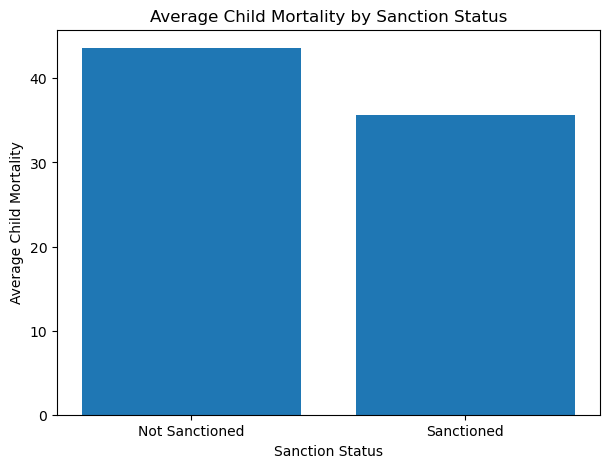

In [9]:
status_summary_df = feature_df.groupby("sanction_active").agg(
    avg_child_mortality=("child_mortality_u5", "mean")
).reset_index()

status_summary_df["sanction_label"] = status_summary_df["sanction_active"].map({
    0: "Not Sanctioned",
    1: "Sanctioned"
})

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(status_summary_df["sanction_label"], status_summary_df["avg_child_mortality"])
ax.set_title("Average Child Mortality by Sanction Status")
ax.set_xlabel("Sanction Status")
ax.set_ylabel("Average Child Mortality")
plt.show()

## Visual 6: Residual Distribution on the Test Set

Residuals are the differences between actual and predicted values. Looking at the residual distribution helps show whether prediction errors are centered near zero or whether the model tends to systematically overpredict or underpredict.

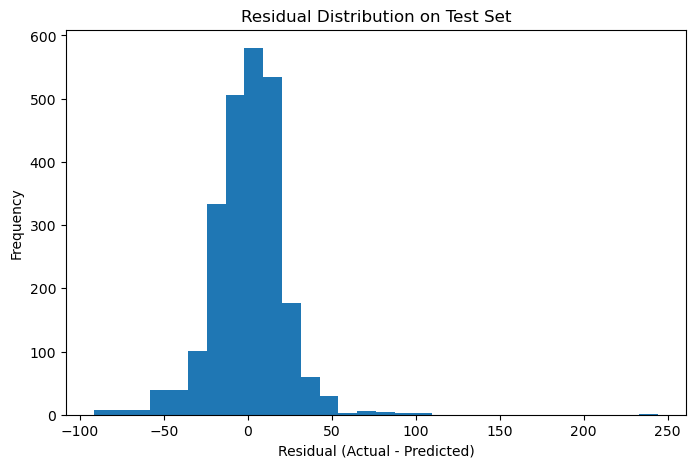

In [10]:
test_preds_df["residual"] = (
    test_preds_df["actual_child_mortality_u5"] -
    test_preds_df["predicted_child_mortality_u5"]
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(test_preds_df["residual"], bins=30)
ax.set_title("Residual Distribution on Test Set")
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Frequency")
plt.show()

## Interactive View: Prediction Error by Year

This widget lets the viewer switch between the actual average child mortality and the average predicted child mortality on the test set. It helps compare how well the model tracks the overall level of the target over time.

In [11]:
test_year_summary = test_preds_df.groupby("year").agg(
    actual_avg=("actual_child_mortality_u5", "mean"),
    predicted_avg=("predicted_child_mortality_u5", "mean")
).reset_index()

year_metric_dropdown = widgets.Dropdown(
    options={
        "Actual Average Child Mortality": "actual_avg",
        "Predicted Average Child Mortality": "predicted_avg"
    },
    value="actual_avg",
    description="View:"
)

def plot_test_year_metric(metric):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(test_year_summary["year"], test_year_summary[metric])
    ax.set_title(f"Test-Set Yearly Trend: {metric.replace('_', ' ').title()}")
    ax.set_xlabel("Year")
    ax.set_ylabel(metric.replace("_", " ").title())
    plt.show()

widgets.interactive(plot_test_year_metric, metric=year_metric_dropdown)

interactive(children=(Dropdown(description='View:', options={'Actual Average Child Mortality': 'actual_avg', '…

## Dashboard Takeaways

This dashboard highlights several key findings from the project.

First, the leakage-reduced linear regression model performs reasonably well, with the strongest performance on training data and somewhat lower performance on validation and test data. This suggests that the model captures meaningful structure, although its predictive power declines on later unseen years.

Second, the actual-versus-predicted plot and residual distribution show that the model tracks broad patterns in child mortality, but prediction errors still remain, especially for some larger values.

Third, the coefficient-based feature view suggests that education, conflict, political context, and sanction-related interaction terms are among the most influential variables in the baseline model. These should be interpreted as associations rather than causal effects.

Finally, the trend views show that average child mortality declines over time, while sanction intensity and the share of sanctioned country-years vary across years. Together, these visuals support the project’s broader goal of exploring how sanctions and contextual conditions relate to civilian well-being.

## Final Note

The dashboard is static in the sense that it runs fully inside the notebook, but the widget controls allow the viewer to switch between different views and comparisons. 

In [12]:
print("Dashboard notebook completed successfully.")

Dashboard notebook completed successfully.
